# Calendar Spread Backtest: Static Dislocation Signal

**Signal:** cross-sectionally demeaned residual from a time-shifted
logit polynomial. Fires when `|resid| > STATIC_THRESHOLD`.

**Execution:** limit orders. If you post at mid (or at bid/ask as liquidity provider),
you typically get filled at that price — so **no spread cost** is the natural assumption
(`SPREAD_HALF = 0`). Use a positive `SPREAD_HALF` only to stress-test as if you were
*taking* liquidity (e.g. market orders) or to be conservative.

**Exit:** when `|resid|` drops below `EXIT_THRESHOLD`, or at resolution.

**Hedge:** equal-weight `-1/(N-1)` on each other node (parallel-shift
neutral). Upgrades to hat-matrix weights when `N > poly_degree + 1`.

**Deduplication:** for 2-node events, symmetric signals fire on both
nodes; we keep only the node with the larger absolute raw move.


In [ ]:
# Ensure project root is on path when running from analytics/
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "analytics" else Path.cwd()
sys.path.insert(0, str(_root))

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import importlib

import curve_pipeline as _cp
importlib.reload(_cp)

from curve_pipeline import (
    build_deadline_market_universe,
    build_history_panel,
    score_time_shifted_dislocations,
    event_ids_poor_static_fit_warmup,
    build_trades_static_dislocation,
    report_non_monotonic_slices,
)

In [24]:
MAX_EVENTS = 1200
MAX_MARKETS = 1200
# CLOB only goes back ~1 month; use 30 days + fidelity to use CLOB data.
LOOKBACK_DAYS = 30
FIDELITY = 60                        # use CLOB fidelity endpoint (~1 month max)
INTERVAL = "1h"                      # hourly bars

STATIC_POLY_DEGREE = 2
STATIC_MIN_NODES = 2
STATIC_LAG = 1                       # 1 bar = 1 hour lag
REF_SMOOTH_BARS = 3                  # smooth ref over 3 bars = 3 hours

STATIC_THRESHOLD = 0.12              # match live
EXIT_THRESHOLD = 0.03

# Simulate top-of-book taker: 1c per side. Sizing matches live (500 shares max per trade).
SPREAD_HALF = 0.01
SHARES_PER_TRADE = 500

EXCLUDE_EVENT_IDS = []
EXCLUDE_POOR_FIT = False               # drop events with worst static-model fit
POOR_FIT_MIN_OBS = 50
POOR_FIT_EXCLUDE_WORST_PCT = 10.0     # exclude worst 10% of events by mean |residual|
POOR_FIT_WARMUP_FRAC = 0.25           # use first 25% of data for poor-fit filter (no lookahead)

# Hat-matrix weight stabilization: fall back to equal-weight if exceeded (avoids leverage blowups)
MAX_WEIGHT_PER_LEG = 1.5           # max |w_i| per hedge leg; None = no cap
MAX_GROSS_HEDGE = 5.0              # max sum(|w_i|); None = no cap


## 1. Build universe

In [25]:
universe_df = build_deadline_market_universe(
    max_events=MAX_EVENTS, min_distinct_dates=2, include_closed=True,
)
print(f"Universe: {len(universe_df)} markets across {universe_df['event_id'].nunique()} events")

universe_df = universe_df[
    ~universe_df["event_id"].isin(EXCLUDE_EVENT_IDS)
]
print(f"After exclusions: {len(universe_df)} markets")

Universe: 487 markets across 140 events
After exclusions: 487 markets


## 2. Fetch price history

In [26]:
panel_df = build_history_panel(
    universe_df, lookback_days=LOOKBACK_DAYS,
    interval=INTERVAL, fidelity=FIDELITY,
    max_markets=MAX_MARKETS,
)
print(f"Panel: {len(panel_df):,} rows, {panel_df['event_id'].nunique()} events")
print(f"Date range: {panel_df['timestamp'].min()} to {panel_df['timestamp'].max()}")

Panel: 197,402 rows, 140 events
Date range: 2026-02-06 11:00:00+00:00 to 2026-03-06 11:00:00+00:00


## 3. Compute static signal

In [46]:
static_df = score_time_shifted_dislocations(
    panel_df,
    lag_bars=STATIC_LAG,
    min_nodes=STATIC_MIN_NODES,
    poly_degree=STATIC_POLY_DEGREE,
    ref_smooth_bars=REF_SMOOTH_BARS,
)
static_df = static_df.dropna(subset=["ts_predicted_prob"])

# Report how many events qualify as poor fit (warmup-only, same params as filter)
_poor_fit_ids = event_ids_poor_static_fit_warmup(
    static_df,
    warmup_frac=POOR_FIT_WARMUP_FRAC,
    min_obs_per_event=POOR_FIT_MIN_OBS,
    exclude_worst_pct=POOR_FIT_EXCLUDE_WORST_PCT,
)
print(f"Poor-fit events (warmup, worst {POOR_FIT_EXCLUDE_WORST_PCT}% by mean |residual|): {len(_poor_fit_ids)}")

warmup_end = None
if EXCLUDE_POOR_FIT:
    ts_min, ts_max = static_df["timestamp"].min(), static_df["timestamp"].max()
    warmup_end = ts_min + (ts_max - ts_min) * POOR_FIT_WARMUP_FRAC
    poor_fit_ids = event_ids_poor_static_fit_warmup(
        static_df,
        warmup_frac=POOR_FIT_WARMUP_FRAC,
        min_obs_per_event=POOR_FIT_MIN_OBS,
        exclude_worst_pct=POOR_FIT_EXCLUDE_WORST_PCT,
    )
    static_df = static_df[~static_df["event_id"].astype(str).isin(poor_fit_ids)]
    print(f"Excluded {len(poor_fit_ids)} events (poor static fit, warmup-only)")
    print(f"Warmup period ends: {warmup_end}")
print(f"Static signal rows: {len(static_df):,}")

static_df["static_flag"] = static_df["ts_residual"].abs() >= STATIC_THRESHOLD
static_df["direction"] = np.where(static_df["ts_residual"] < 0, "BUY", "SELL")

signals = static_df[static_df["static_flag"]].copy()
if warmup_end is not None:
    signals = signals[signals["timestamp"] > warmup_end]
print(f"Entry signals (post-warmup): {len(signals):,}")
if not signals.empty:
    print(f"  Unique (event, deadline) pairs: {signals.groupby(['event_id', 'deadline_date']).ngroups}")

Poor-fit events (warmup, worst 10.0% by mean |residual|): 9
Static signal rows: 161,622
Entry signals (post-warmup): 2,925
  Unique (event, deadline) pairs: 87


## 4. Construct trades

In [28]:
def compute_hedge_weights(j_idx, N, taus, poly_degree, max_weight_per_leg=None, max_gross_hedge=None):
    """Equal-weight for underdetermined, hat-matrix for overdetermined.
    If max_weight_per_leg or max_gross_hedge is exceeded, fall back to equal-weight to avoid leverage blowups.
    """
    w_each = -1.0 / (N - 1)
    equal_weight = {i: w_each for i in range(N) if i != j_idx}
    if N <= poly_degree + 1:
        return equal_weight

    taus = np.asarray(taus, dtype=float)
    deg = min(poly_degree, N - 1)
    X = np.vander(taus, N=deg + 1, increasing=False)
    try:
        H = X @ np.linalg.solve(X.T @ X, X.T)
    except np.linalg.LinAlgError:
        H = X @ np.linalg.lstsq(X.T @ X, X.T, rcond=None)[0]

    h_row = H[j_idx]
    denom = 1.0 - h_row[j_idx]
    if abs(denom) < 1e-10:
        return equal_weight

    weights = {}
    for i in range(N):
        if i == j_idx:
            continue
        w = -h_row[i] / denom
        if abs(w) > 1e-8:
            weights[i] = w
    if not weights:
        return equal_weight

    # Stabilization: fall back to equal-weight if hat-matrix weights are too large
    w_vals = list(weights.values())
    max_w = max(abs(x) for x in w_vals)
    gross = sum(abs(x) for x in w_vals)
    if (max_weight_per_leg is not None and max_w > max_weight_per_leg) or \
       (max_gross_hedge is not None and gross > max_gross_hedge):
        return equal_weight
    return weights


resolution_map = universe_df.dropna(subset=["resolution"]).set_index(
    ["event_id", "deadline_date"]
)["resolution"].to_dict()

event_deadlines = panel_df.groupby("event_id")["deadline_date"].apply(
    lambda x: sorted(x.unique())
).to_dict()

latest_prices = (
    panel_df.sort_values("timestamp")
    .groupby(["event_id", "deadline_date"])
    .last()["probability_yes"]
    .to_dict()
)


def build_trades(signals_df, panel, static_signal_df, resolution_map,
                 event_deadlines, latest_prices, exit_threshold, poly_degree,
                 spread_half=0.0, max_weight_per_leg=None, max_gross_hedge=None):
    trades = []

    _evt_ts = {}
    for _eid, _grp in panel.groupby("event_id"):
        _evt_ts[_eid] = sorted(_grp["timestamp"].unique())
    event_last_ts = panel.groupby("event_id")["timestamp"].max().to_dict()

    # Re-entry policy:
    # - allow re-entry on a (event, deadline) only after prior trade on that pair has effectively closed
    # - enforce at most one active trade per event at any point in time
    earliest_ts = panel["timestamp"].min()
    event_next_available = {}
    pair_next_available = {}

    signals_sorted = signals_df.sort_values("timestamp").reset_index(drop=True)

    for _, sig in signals_sorted.iterrows():
        eid = sig["event_id"]
        dd = sig["deadline_date"]
        ts_signal = sig["timestamp"]
        direction = sig["direction"]

        if ts_signal < event_next_available.get(eid, earliest_ts):
            continue
        if ts_signal < pair_next_available.get((eid, dd), earliest_ts):
            continue

        evt_ts_list = _evt_ts.get(eid, [])
        sig_idx = next((i for i, t in enumerate(evt_ts_list) if t >= ts_signal), None)
        if sig_idx is None or sig_idx + 1 >= len(evt_ts_list):
            continue
        ts = evt_ts_list[sig_idx + 1]
        _entry_row = panel[
            (panel["event_id"] == eid) &
            (panel["deadline_date"] == dd) &
            (panel["timestamp"] == ts)
        ]
        if _entry_row.empty:
            continue
        price = _entry_row.iloc[0]["probability_yes"]

        deadlines = event_deadlines.get(eid, [])
        if dd not in deadlines:
            continue
        j_idx = deadlines.index(dd)
        N = len(deadlines)

        entry_snap = panel[
            (panel["event_id"] == eid) & (panel["timestamp"] == ts)
        ]
        if entry_snap.empty:
            continue

        tau_map = entry_snap.groupby("deadline_date")["tau_days"].first()
        taus = [tau_map.get(d, np.nan) for d in deadlines]
        if any(np.isnan(t) for t in taus):
            available = [(i, d) for i, d in enumerate(deadlines) if d in tau_map.index]
            if len(available) < 2:
                continue
            taus = [tau_map[d] for _, d in available]
            deadlines_local = [d for _, d in available]
            j_idx = next((k for k, (_, d) in enumerate(available) if d == dd), None)
            if j_idx is None:
                continue
            N = len(deadlines_local)
        else:
            deadlines_local = deadlines

        hedge_weights = compute_hedge_weights(j_idx, N, taus, poly_degree,
            max_weight_per_leg=max_weight_per_leg, max_gross_hedge=max_gross_hedge)
        if not hedge_weights:
            continue

        # Effective entry/exit with bid-ask: we pay ask (mid + half) when buying, receive bid (mid - half) when selling
        entry_dis = price
        if spread_half > 0:
            entry_dis_eff = (price + spread_half) if direction == "BUY" else (price - spread_half)
        else:
            entry_dis_eff = price

        # Exit: walk forward until |resid| < exit_threshold
        future = static_signal_df[
            (static_signal_df["event_id"] == eid) &
            (static_signal_df["deadline_date"] == dd) &
            (static_signal_df["timestamp"] > ts)
        ].sort_values("timestamp")

        exit_rows = future[future["ts_residual"].abs() < exit_threshold]
        exit_ts = None
        exit_price_dis = None
        exit_status = None
        if not exit_rows.empty:
            _exit_sig_ts = exit_rows.iloc[0]["timestamp"]
            _xi = next((i for i, t in enumerate(evt_ts_list) if t >= _exit_sig_ts), None)
            if _xi is not None and _xi + 1 < len(evt_ts_list):
                exit_ts = evt_ts_list[_xi + 1]
                _xrow = panel[
                    (panel["event_id"] == eid) &
                    (panel["deadline_date"] == dd) &
                    (panel["timestamp"] == exit_ts)
                ]
                if not _xrow.empty:
                    exit_price_dis = _xrow.iloc[0]["probability_yes"]
                    exit_status = "E"
        if exit_status is None:
            exit_ts = None
            dis_res = resolution_map.get((eid, dd))
            dis_resolved = (dis_res is not None and
                            not (isinstance(dis_res, float) and np.isnan(dis_res)))
            if dis_resolved:
                exit_price_dis = dis_res
                exit_status = "R"
            else:
                exit_price_dis = latest_prices.get((eid, dd), price)
                exit_status = "P"

        # Effective close time for concurrency controls:
        # unresolved exits (R/P) remain active through the end of sampled history for that event.
        effective_end_ts = exit_ts if (exit_status == "E" and exit_ts is not None) else event_last_ts.get(eid, ts)

        if spread_half > 0:
            exit_eff = (exit_price_dis - spread_half) if direction == "BUY" else (exit_price_dis + spread_half)
            pnl_dis = (exit_eff - entry_dis_eff) if direction == "BUY" else (entry_dis_eff - exit_eff)
        else:
            pnl_dis = (exit_price_dis - entry_dis) if direction == "BUY" else (entry_dis - exit_price_dis)

        # Hedge legs
        legs = []
        all_ok = True
        for h_idx, w in hedge_weights.items():
            hedge_dd = deadlines_local[h_idx]
            h_sub = panel[
                (panel["event_id"] == eid) & (panel["deadline_date"] == hedge_dd)
            ].drop_duplicates(subset=["timestamp"], keep="last").set_index("timestamp").sort_index()
            if h_sub.empty:
                all_ok = False; break
            idx = h_sub.index.get_indexer([ts], method="nearest")[0]
            if idx < 0 or idx >= len(h_sub):
                all_ok = False; break
            if abs((h_sub.index[idx] - ts).total_seconds()) > 7200:
                all_ok = False; break
            h_entry = h_sub.iloc[idx]["probability_yes"]

            if exit_status == "E" and exit_ts is not None:
                eidx = h_sub.index.get_indexer([exit_ts], method="nearest")[0]
                if (0 <= eidx < len(h_sub) and
                        abs((h_sub.index[eidx] - exit_ts).total_seconds()) <= 7200):
                    h_exit = h_sub.iloc[eidx]["probability_yes"]
                    h_stat = "E"
                else:
                    h_exit = latest_prices.get((eid, hedge_dd), h_entry)
                    h_stat = "P"
            elif exit_status == "R":
                hr = resolution_map.get((eid, hedge_dd))
                if hr is not None and not (isinstance(hr, float) and np.isnan(hr)):
                    h_exit = hr; h_stat = "R"
                else:
                    h_exit = latest_prices.get((eid, hedge_dd), h_entry); h_stat = "P"
            else:
                h_exit = latest_prices.get((eid, hedge_dd), h_entry); h_stat = "P"

            if direction == "BUY":
                pnl_h = abs(w) * ((h_entry - h_exit) if w < 0 else (h_exit - h_entry))
            else:
                pnl_h = abs(w) * ((h_exit - h_entry) if w < 0 else (h_entry - h_exit))
            if spread_half > 0:
                pnl_h -= 2 * spread_half * abs(w)

            legs.append({
                "hedge_dd": hedge_dd, "weight": round(w, 4),
                "entry": round(h_entry, 4), "status": h_stat,
                "exit_val": round(h_exit, 4), "pnl": round(pnl_h, 4),
            })

        if not all_ok or not legs:
            continue

        total_pnl = pnl_dis + sum(l["pnl"] for l in legs)

        if exit_status == "E" and exit_ts is not None:
            hold_sec = (exit_ts - ts).total_seconds()
            hold_h = hold_sec / 3600
            hold_str = f"{hold_h:.1f}h"
        else:
            hold_str = "—"

        hedge_summary = "; ".join(
            f"{l['hedge_dd']}({l['weight']:+.3f})@{l['entry']:.3f}{l['status']}"
            for l in legs
        )

        primary_h = max(legs, key=lambda l: abs(l["weight"]))["hedge_dd"]
        spread_dir = ("steepen" if direction == "SELL" else "flatten") if dd < primary_h else (
            "steepen" if direction == "BUY" else "flatten")

        q_rows = panel[panel["event_id"] == eid]
        event_name = q_rows["question"].iloc[0][:50] if not q_rows.empty else eid

        trades.append({
            "event": event_name, "event_id": eid,
            "entry_ts": ts, "exit_ts": exit_ts, "hold_time": hold_str,
            "spread_type": spread_dir, "status": exit_status,
            "dis_node": dd, "dis_entry": round(entry_dis, 4),
            "dis_exit": round(exit_price_dis, 4), "dis_pnl": round(pnl_dis, 4),
            "hedge_legs": hedge_summary,
            "hedge_pnl": round(sum(l["pnl"] for l in legs), 4),
            "spread_pnl": round(total_pnl, 4),
            "static_resid": round(sig["ts_residual"], 4),
            "n_nodes": N,
        })

        # availability updates enforce max 1 concurrent trade per event
        event_next_available[eid] = effective_end_ts
        pair_next_available[(eid, dd)] = effective_end_ts

    _cols = ["event", "event_id", "entry_ts", "exit_ts", "hold_time",
             "spread_type", "status", "dis_node", "dis_entry", "dis_exit",
             "dis_pnl", "hedge_legs", "hedge_pnl", "spread_pnl",
             "static_resid", "n_nodes"]
    return pd.DataFrame(trades, columns=_cols) if trades else pd.DataFrame(columns=_cols)


first_signals = signals.sort_values("timestamp").copy()
print(f"Candidate entry signals (re-entry enabled): {len(first_signals)}")

# #region agent log
import json as _json, time as _time
_logpath = "/Users/AnranSeverac/YieldCurveModel/.cursor/debug-b98a4f.log"
_log_data = {
    "sessionId": "b98a4f", "runId": "run1", "hypothesisId": "H-B,H-D",
    "location": "backtest:cell10:pre_build", "timestamp": int(_time.time()*1000),
    "message": "pre_build_trades",
    "data": {
        "first_signals_count": len(first_signals),
        "signals_count": len(signals),
        "event_deadlines_count": len(event_deadlines),
        "event_deadlines_key_types": str(type(list(event_deadlines.keys())[0])) if event_deadlines else "empty",
        "event_deadlines_sample": {str(k): [str(d) for d in v[:3]] for k, v in list(event_deadlines.items())[:2]} if event_deadlines else {},
        "resolution_map_count": len(resolution_map),
        "latest_prices_count": len(latest_prices),
        "signal_eid_dtype": str(first_signals["event_id"].dtype) if not first_signals.empty else "empty",
        "signal_sample_eids": list(first_signals["event_id"].head(3).astype(str)) if not first_signals.empty else [],
        "panel_eid_dtype": str(panel_df["event_id"].dtype),
    }
}
with open(_logpath, "a") as _f:
    _f.write(_json.dumps(_log_data) + "\n")
# #endregion

trades_df = build_trades_static_dislocation(
    first_signals,
    panel_df,
    static_df,
    exit_threshold=EXIT_THRESHOLD,
    poly_degree=STATIC_POLY_DEGREE,
    resolution_map=resolution_map,
    event_deadlines=event_deadlines,
    latest_prices=latest_prices,
    spread_half=SPREAD_HALF,
    max_weight_per_leg=MAX_WEIGHT_PER_LEG,
    max_gross_hedge=MAX_GROSS_HEDGE,
    shares_per_trade=SHARES_PER_TRADE,
)

print(f"Trades constructed: {len(trades_df)}")
if not trades_df.empty:
    for s in ["E", "R", "P"]:
        n = (trades_df["status"] == s).sum()
        if n > 0:
            label = {"E": "Exited (signal)", "R": "Resolved", "P": "Pending (MtM)"}[s]
            print(f"  {label}: {n}")

Candidate entry signals (re-entry enabled): 2925
Trades constructed: 105
  Exited (signal): 98
  Pending (MtM): 7


## 5. Deduplicate symmetric 2-node pairs

In [29]:
def get_raw_moves(panel, event_id, entry_ts, lag=STATIC_LAG):
    evdf = panel[panel["event_id"] == event_id]
    all_ts = sorted(evdf["timestamp"].unique())
    ts_arr = pd.DatetimeIndex(all_ts)
    nearest_idx = ts_arr.get_indexer([entry_ts], method="nearest")[0]
    if nearest_idx < lag:
        return {}
    actual_ts = all_ts[nearest_idx]
    ref_ts = all_ts[nearest_idx - lag]
    snap = evdf[evdf["timestamp"] == actual_ts]
    ref_snap = evdf[evdf["timestamp"] == ref_ts]
    moves = {}
    for _, row in snap.iterrows():
        dd = row["deadline_date"]
        ref_row = ref_snap[ref_snap["deadline_date"] == dd]
        if not ref_row.empty:
            moves[dd] = row["probability_yes"] - ref_row.iloc[0]["probability_yes"]
    return moves


if trades_df.empty:
    deduped_df = trades_df.copy()
    print(f"Before dedup: 0  →  After dedup: 0")
else:
    grouped = trades_df.groupby(["event_id", "entry_ts"])
    deduped_rows = []
    for (eid, ets), group in grouped:
        if len(group) == 1:
            deduped_rows.append(group.iloc[0])
            continue
        if len(group) == 2 and group["n_nodes"].iloc[0] == 2:
            raw_moves = get_raw_moves(panel_df, eid, ets)
            best_idx, best_abs = None, -1
            for i2, (_, row) in enumerate(group.iterrows()):
                rm = abs(raw_moves.get(row["dis_node"], 0))
                if rm > best_abs:
                    best_abs = rm; best_idx = i2
            deduped_rows.append(group.iloc[best_idx or 0])
        else:
            deduped_rows.append(group.loc[group["static_resid"].abs().idxmax()])

    deduped_df = pd.DataFrame(deduped_rows).reset_index(drop=True)
    print(f"Before dedup: {len(trades_df)}  →  After dedup: {len(deduped_df)}")

Before dedup: 105  →  After dedup: 105


## 6. Results

CALENDAR SPREAD TRADES (static signal, demeaned, limit-order)
E = exited (signal dissipated)  |  R = resolved  |  P = pending (MtM)


,event,entry_ts,hold_time,status,spread_type,dis_node,dis_entry,dis_exit,dis_pnl,hedge_legs,hedge_pnl,spread_pnl,spread_pnl_dollars,shares,static_resid,n_nodes
0,Will Russia enter Dobropillia by...?,2026-02-20 19:00:00+00:00,2.0h,E,flatten,2026-04-30,0.260,0.260,-0.020,2026-03-31(-1.000)@0.110E,-0.0200,-0.0400,-20.00,500.0,0.1592,2
1,Will Russia enter Dobropillia by...?,2026-02-21 12:00:00+00:00,3.0h,E,steepen,2026-03-31,0.110,0.110,-0.020,2026-04-30(-1.000)@0.055E,-0.0300,-0.0500,-25.00,500.0,0.1658,2
2,Will Russia enter Dobropillia by...?,2026-02-21 22:00:00+00:00,3.0h,E,flatten,2026-04-30,0.520,0.520,-0.020,2026-03-31(-1.000)@0.095E,-0.0200,-0.0400,-20.00,500.0,0.2125,2
3,Will Russia enter Dobropillia by...?,2026-02-27 02:00:00+00:00,3.0h,E,steepen,2026-04-30,0.160,0.165,-0.015,2026-03-31(-1.000)@0.130E,-0.0200,-0.0350,-17.50,500.0,-0.1375,2
4,Will Russia enter Dobropillia by...?,2026-03-04 00:00:00+00:00,3.0h,E,flatten,2026-04-30,0.205,0.165,0.020,2026-03-31(-1.000)@0.095E,-0.0250,-0.0050,-2.50,500.0,0.1517,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Will fomo.family launch a token by ___ ?,2026-03-01 02:00:00+00:00,2.0h,E,flatten,2026-12-31,0.350,0.315,0.015,2026-03-31(-0.333)@0.045E; 2026-06-30(-0.333)@0.130...,-0.0201,-0.0051,-2.55,500.0,0.1275,4
101,Will fomo.family launch a token by ___ ?,2026-03-01 08:00:00+00:00,3.0h,E,flatten,2026-09-30,0.260,0.230,0.010,2026-03-31(+0.338)@0.050E; 2026-06-30(-1.006)@0.085...,-0.0336,-0.0236,-11.80,500.0,0.2070,4
102,Will fomo.family launch a token by ___ ?,2026-03-04 22:00:00+00:00,15.0h,E,flatten,2026-09-30,0.345,0.130,0.195,2026-03-31(+0.338)@0.037E; 2026-06-30(-1.006)@0.125...,-0.0386,0.1564,78.20,500.0,0.1360,4
103,Microstrategy delisted from MSCI index by...?,2026-02-08 22:00:00+00:00,3.0h,E,steepen,2026-12-31,0.690,0.770,0.060,2026-03-31(-0.500)@0.084E; 2026-06-30(-0.500)@0.255E,0.0240,0.0840,42.00,500.0,-0.1301,3



──────────────────────────────────────────────────
SUMMARY
──────────────────────────────────────────────────
Total trades:    105
Total PnL ($):   $1,387.90  (CLOB 1mo, 1c spread, SHARES_PER_TRADE/trade)
  Exited: 98
  Pending: 7

Realized (E only):
  Count:          98
  Mean spread PnL:0.0279
  Total PnL:      2.7370
  Win/Loss/BE:    50/48/0
  Hit rate:       51.0%

Closed (E+R, excluding pending MtM):
  Count:          98
  Mean spread PnL:0.0279
  Total PnL:      2.7370

All trades (includes pending MtM):
  Mean spread PnL:0.0264
  Total PnL:      2.7758
  Win/Loss/BE:    54/51/0
  Hit rate:       51.4%

Spread-cost stress test (pre-dedup, same signals):
  spread_half=0.000: n=105, mean=0.0737, total=7.7342
  spread_half=0.005: n=105, mean=0.0501, total=5.2558
  spread_half=0.010: n=105, mean=0.0264, total=2.7758


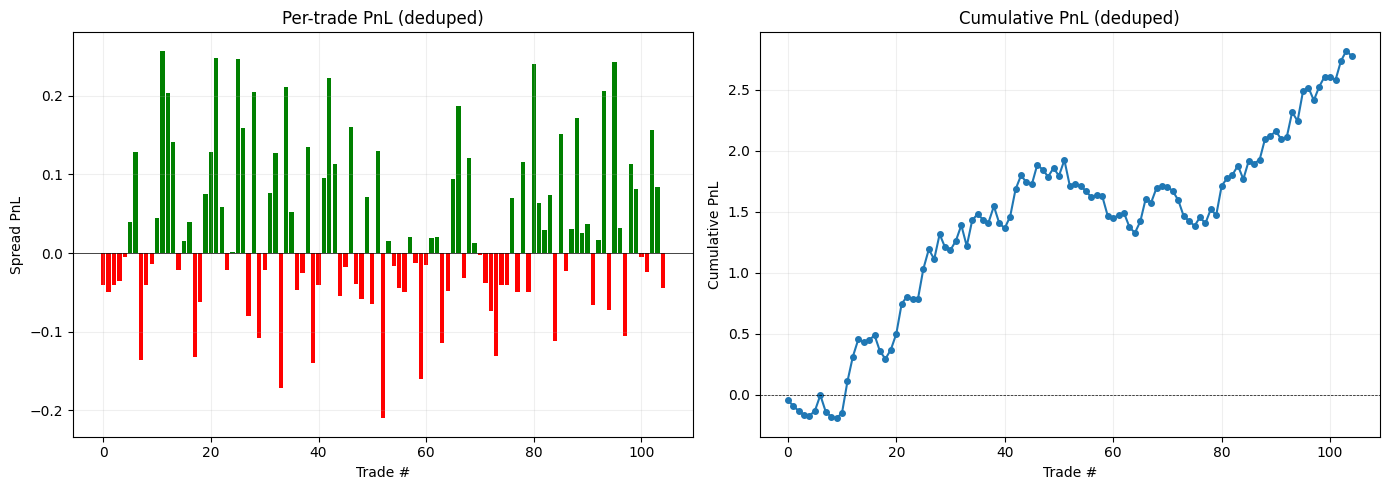

In [30]:
results = deduped_df
if not results.empty:
    display_cols = [
        "event", "entry_ts", "hold_time", "status", "spread_type",
        "dis_node", "dis_entry", "dis_exit", "dis_pnl",
        "hedge_legs", "hedge_pnl", "spread_pnl", "spread_pnl_dollars", "shares", "static_resid", "n_nodes",
    ]
    if "spread_pnl_dollars" not in results.columns:
        display_cols = [c for c in display_cols if c not in ("spread_pnl_dollars", "shares")]
    print("=" * 90)
    print("CALENDAR SPREAD TRADES (static signal, demeaned, limit-order)")
    print("E = exited (signal dissipated)  |  R = resolved  |  P = pending (MtM)")
    print("=" * 90)
    pd.set_option('display.max_colwidth', 55)
    display(results[display_cols])

    print(f"\n{'─' * 50}")
    print("SUMMARY")
    print(f"{'─' * 50}")
    print(f"Total trades:    {len(results)}")
    if "spread_pnl_dollars" in results.columns:
        total_dollars = results["spread_pnl_dollars"].sum()
        print(f"Total PnL ($):   ${total_dollars:,.2f}  (CLOB 1mo, 1c spread, SHARES_PER_TRADE/trade)")
    for s, lbl in [("E", "Exited"), ("R", "Resolved"), ("P", "Pending")]:
        n = (results["status"] == s).sum()
        if n: print(f"  {lbl}: {n}")
    exited = results[results["status"] == "E"].copy()
    non_pending = results[results["status"].isin(["E", "R"])].copy()

    if len(exited) > 0:
        w_e = (exited["spread_pnl"] > 0).sum()
        l_e = (exited["spread_pnl"] < 0).sum()
        print("\nRealized (E only):")
        print(f"  Count:          {len(exited)}")
        print(f"  Mean spread PnL:{exited['spread_pnl'].mean():.4f}")
        print(f"  Total PnL:      {exited['spread_pnl'].sum():.4f}")
        print(f"  Win/Loss/BE:    {w_e}/{l_e}/{len(exited)-w_e-l_e}")
        if (w_e + l_e) > 0:
            print(f"  Hit rate:       {w_e/(w_e+l_e):.1%}")

    if len(non_pending) > 0:
        print("\nClosed (E+R, excluding pending MtM):")
        print(f"  Count:          {len(non_pending)}")
        print(f"  Mean spread PnL:{non_pending['spread_pnl'].mean():.4f}")
        print(f"  Total PnL:      {non_pending['spread_pnl'].sum():.4f}")

    w_all = (results["spread_pnl"] > 0).sum()
    l_all = (results["spread_pnl"] < 0).sum()
    print("\nAll trades (includes pending MtM):")
    print(f"  Mean spread PnL:{results['spread_pnl'].mean():.4f}")
    print(f"  Total PnL:      {results['spread_pnl'].sum():.4f}")
    print(f"  Win/Loss/BE:    {w_all}/{l_all}/{len(results)-w_all-l_all}")
    if (w_all + l_all) > 0:
        print(f"  Hit rate:       {w_all/(w_all+l_all):.1%}")

    print("\nSpread-cost stress test (pre-dedup, same signals):")
    for sh in [0.0, 0.005, 0.01]:
        t_stress = build_trades_static_dislocation(
            first_signals,
            panel_df,
            static_df,
            exit_threshold=EXIT_THRESHOLD,
            poly_degree=STATIC_POLY_DEGREE,
            resolution_map=resolution_map,
            event_deadlines=event_deadlines,
            latest_prices=latest_prices,
            spread_half=sh,
            max_weight_per_leg=MAX_WEIGHT_PER_LEG,
            max_gross_hedge=MAX_GROSS_HEDGE,
        )
        if t_stress.empty:
            print(f"  spread_half={sh:.3f}: no trades")
        else:
            print(
                f"  spread_half={sh:.3f}: n={len(t_stress)}, "
                f"mean={t_stress['spread_pnl'].mean():.4f}, "
                f"total={t_stress['spread_pnl'].sum():.4f}"
            )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(range(len(results)), results["spread_pnl"],
                color=["green" if x > 0 else "red" for x in results["spread_pnl"]])
    axes[0].axhline(0, color="black", linewidth=0.5)
    axes[0].set_xlabel("Trade #"); axes[0].set_ylabel("Spread PnL")
    axes[0].set_title("Per-trade PnL (deduped)"); axes[0].grid(True, alpha=0.2)

    axes[1].plot(results["spread_pnl"].cumsum().values, marker="o", markersize=4)
    axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
    axes[1].set_xlabel("Trade #"); axes[1].set_ylabel("Cumulative PnL")
    axes[1].set_title("Cumulative PnL (deduped)"); axes[1].grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("No trades generated.")

## 7. Live execution

Live execution is split out into `live_execution.py` for speed and background operation.
The backtest notebook remains focused on research, diagnostics, and performance attribution.

## 8. Sample trade curves (5 random)

For 5 randomly selected trades (exited by signal): **left** = curve at entry (actual + fair value); **right** = actual at exit vs fair value at entry (to see if the curve reverted to the shape you expected at entry).

**When the curve decreases:** For "will X happen by date D?", probability should be non-decreasing in D. If you see the curve *decrease* at a tenor, the actual market is missing for that point—either an issue in how we're processing (e.g. wrong token, wrong deadline mapping, or including a slot that has no real market) or an issue with the data. Fix the cause; we don't truncate or mask it here.

**Dis node:** The vertical "Dis node" marks the tenor we traded. We entered because Actual was *rich* vs Fair (positive residual). After exit, Actual and Fair can realign or stay apart depending on how the trade resolved. That’s a data/universe issue, not a bug in the plot.

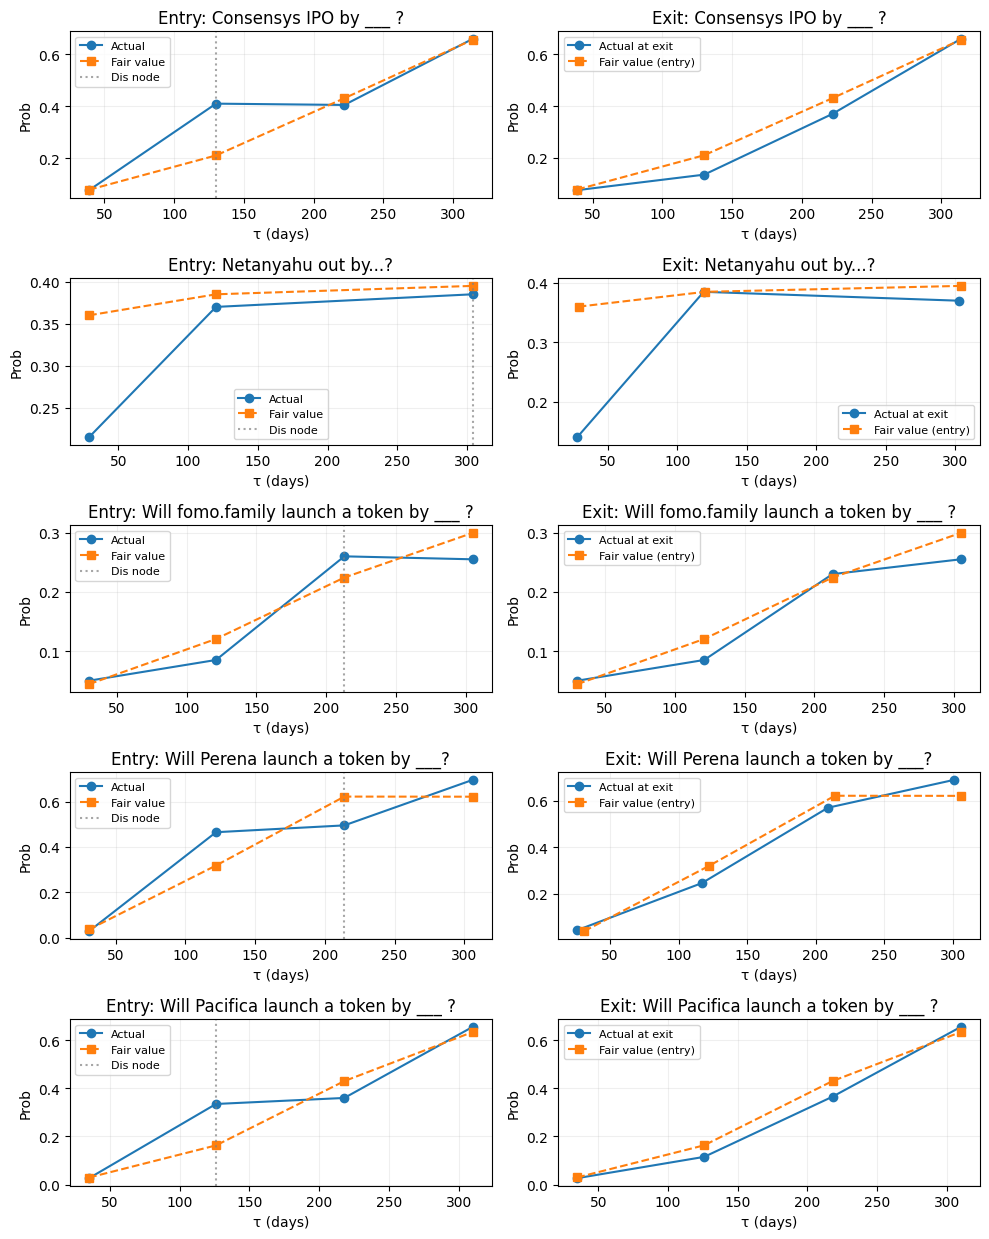

In [31]:
# 5 random trades with exit (so we have exit curve)
try:
    _trades = deduped_df
except NameError:
    _trades = trades_df
eligible = _trades[_trades["status"] == "E"].dropna(subset=["exit_ts"])
if eligible.empty:
    print("No exited trades to plot.")
else:
    n_show = min(5, len(eligible))
    sample = eligible.sample(n=n_show, random_state=42).reset_index(drop=True)

    fig, axes = plt.subplots(n_show, 2, figsize=(10, 2.5 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)

    for i, (_, row) in enumerate(sample.iterrows()):
        eid, entry_ts, exit_ts = row["event_id"], row["entry_ts"], row["exit_ts"]
        dis_node = row["dis_node"]
        title = str(row["event"])[:45] + "..." if len(str(row["event"])) > 45 else str(row["event"])

        # Entry: actual curve from panel, fair from static_df. One row per deadline, sorted by tau.
        entry_snap = panel_df[(panel_df["event_id"] == eid) & (panel_df["timestamp"] == entry_ts)]
        entry_snap = entry_snap.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
        if entry_snap.empty:
            axes[i, 0].text(0.5, 0.5, "No entry data", ha="center", va="center")
            axes[i, 0].set_title(f"Entry: {title}")
        else:
            tau = entry_snap["tau_days"].values
            actual = entry_snap["probability_yes"].values.astype(float)
            static_entry = static_df[(static_df["event_id"] == eid) & (static_df["timestamp"] == entry_ts)]
            static_entry = static_entry.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
            axes[i, 0].plot(tau, actual, "o-", label="Actual", color="C0")
            if not static_entry.empty and len(static_entry) == len(entry_snap):
                fair = static_entry["ts_predicted_prob"].values.astype(float)
                tau_f = static_entry["tau_days"].values
                axes[i, 0].plot(tau_f, fair, "s--", label="Fair value", color="C1")
            dis_tau = entry_snap[entry_snap["deadline_date"].astype(str) == str(dis_node)]["tau_days"].values
            if len(dis_tau) and dis_node in entry_snap["deadline_date"].values:
                axes[i, 0].axvline(dis_tau[0], color="gray", linestyle=":", alpha=0.7, label="Dis node")
            axes[i, 0].set_xlabel("τ (days)"); axes[i, 0].set_ylabel("Prob")
            axes[i, 0].set_title(f"Entry: {title}"); axes[i, 0].legend(loc="best", fontsize=8); axes[i, 0].grid(True, alpha=0.2)

        # Exit: actual at exit + fair value at entry (to see if curve reverted to entry-time fair shape)
        exit_snap = panel_df[(panel_df["event_id"] == eid) & (panel_df["timestamp"] == exit_ts)]
        exit_snap = exit_snap.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
        if exit_snap.empty:
            axes[i, 1].text(0.5, 0.5, "No exit data", ha="center", va="center")
        else:
            tau_ex = exit_snap["tau_days"].values
            actual_ex = exit_snap["probability_yes"].values.astype(float)
            axes[i, 1].plot(tau_ex, actual_ex, "o-", color="C0", label="Actual at exit")
            fair_at_entry = static_df[(static_df["event_id"] == eid) & (static_df["timestamp"] == entry_ts)]
            fair_at_entry = fair_at_entry.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
            if not fair_at_entry.empty:
                tau_f = fair_at_entry["tau_days"].values
                fair = fair_at_entry["ts_predicted_prob"].values.astype(float)
                axes[i, 1].plot(tau_f, fair, "s--", color="C1", label="Fair value (entry)")
            axes[i, 1].set_xlabel("τ (days)"); axes[i, 1].set_ylabel("Prob")
            axes[i, 1].set_title(f"Exit: {title}"); axes[i, 1].legend(loc="best", fontsize=8); axes[i, 1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

In [33]:
# Diagnostic: for one event with a decreasing curve, show universe + panel so we can spot wrong deadline/token.
if not non_mono.empty and "universe_df" in dir():
    row = non_mono.iloc[0]
    eid, ts = row["event_id"], row["timestamp"]
    print(f"Event {eid} at {ts} — first decrease at deadline {row['deadline_date']} (tau={row['tau_days']}d, prob={row['probability_yes']:.3f}, prev={row['prev_probability_yes']:.3f})")
    u = universe_df[universe_df["event_id"] == eid][["market_question", "deadline_date", "yes_token_id"]].sort_values("deadline_date")
    print("Universe (markets we use per deadline):"); display(u)
    p = panel_df[(panel_df["event_id"] == eid) & (panel_df["timestamp"] == ts)].sort_values("tau_days")
    p = p.merge(u.rename(columns={"market_question": "universe_question"})[["deadline_date", "yes_token_id", "universe_question"]], on=["deadline_date", "yes_token_id"], how="left")
    print("Panel at this timestamp (tau_days, probability_yes, and which market question):"); print(p[["deadline_date", "tau_days", "probability_yes", "yes_token_id", "universe_question"]].to_string())
else:
    print("Run the cell above first; need non_mono and universe_df.")

Event 100406 at 2026-02-21 11:00:00+00:00 — first decrease at deadline 2026-04-30 (tau=68d, prob=0.055, prev=0.110)
Universe (markets we use per deadline):


,market_question,deadline_date,yes_token_id
0,Will Russia enter Dobropillia by March 31?,2026-03-31,632035299341118720383159509100938727130513949011658...
1,Will Russia enter Dobropillia by April 30?,2026-04-30,552231868768087608392805728330899503108339872650856...
2,Will Russia enter Dobropillia by January 31?,2027-01-31,102450343404204093388045637822412969648851763955045...


Panel at this timestamp (tau_days, probability_yes, and which market question):
  deadline_date  tau_days  probability_yes                                                                   yes_token_id                           universe_question
0    2026-03-31        38            0.110  63203529934111872038315950910093872713051394901165839307305322106538654524261  Will Russia enter Dobropillia by March 31?
1    2026-04-30        68            0.055  55223186876808760839280572833089950310833987265085657403735781563502578684920  Will Russia enter Dobropillia by April 30?


## 9. Shape L²: fair at entry vs actual at entry as predictor of exit curve

For each exited trade, compute the **normalized L² norm of the shape residual** (after projecting out the best-fit parallel shift) between:
- actual at exit vs **fair at entry**
- actual at exit vs **actual at entry**

If fair at entry is a better approximation of the future curve shape, we expect L²(fair→exit) < L²(actual→exit) on average. Curves are aligned on common tenors (deadline_date) and the parallel shift is removed so the metric matches the parallel-shift-neutral signal and hedge.

In [36]:
try:
    _trades = deduped_df
except NameError:
    _trades = trades_df
exited = _trades[_trades["status"] == "E"].dropna(subset=["exit_ts"])

def normalized_l2_shape(actual_exit, reference):
    """L² norm of shape residual (demean the difference) / sqrt(N)."""
    diff = np.asarray(actual_exit, dtype=float) - np.asarray(reference, dtype=float)
    diff = diff - np.nanmean(diff)
    n = np.sum(np.isfinite(diff))
    if n < 2:
        return np.nan
    return float(np.sqrt(np.nansum(diff**2) / n))

rows = []
for _, row in exited.iterrows():
    eid, entry_ts, exit_ts = row["event_id"], row["entry_ts"], row["exit_ts"]
    entry_snap = panel_df[(panel_df["event_id"] == eid) & (panel_df["timestamp"] == entry_ts)]
    entry_snap = entry_snap.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
    exit_snap = panel_df[(panel_df["event_id"] == eid) & (panel_df["timestamp"] == exit_ts)]
    exit_snap = exit_snap.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
    common_dd = set(entry_snap["deadline_date"]) & set(exit_snap["deadline_date"])
    if len(common_dd) <= 2:
        continue  # restrict to more than 2 nodes
    entry_snap = entry_snap[entry_snap["deadline_date"].isin(common_dd)].sort_values("tau_days")
    exit_snap = exit_snap[exit_snap["deadline_date"].isin(common_dd)].sort_values("tau_days")
    actual_entry = entry_snap["probability_yes"].values.astype(float)
    actual_ex = exit_snap["probability_yes"].values.astype(float)
    if len(actual_entry) != len(actual_ex):
        continue
    l2_actual = normalized_l2_shape(actual_ex, actual_entry)
    static_entry = static_df[(static_df["event_id"] == eid) & (static_df["timestamp"] == entry_ts)]
    static_entry = static_entry.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
    static_entry = static_entry[static_entry["deadline_date"].isin(common_dd)].sort_values("tau_days")
    if len(static_entry) == len(actual_ex):
        fair_entry = static_entry["ts_predicted_prob"].values.astype(float)
        l2_fair = normalized_l2_shape(actual_ex, fair_entry)
    else:
        l2_fair = np.nan
    rows.append({"event_id": eid, "event": row.get("event", ""), "L2_fair": l2_fair, "L2_actual": l2_actual, "N": len(common_dd)})

shape_df = pd.DataFrame(rows)
if shape_df.empty:
    print("No exited trades with common tenors at entry and exit.")
else:
    display(shape_df)
    valid = shape_df.dropna(subset=["L2_fair"])
    if not valid.empty:
        fair_better = (valid["L2_fair"] < valid["L2_actual"]).sum()
        print(f"\nFair at entry better (L2_fair < L2_actual): {fair_better} / {len(valid)} trades")
        print(f"Mean L2 (shape) fair to exit: {valid['L2_fair'].mean():.4f}")
        print(f"Mean L2 (shape) actual to exit: {valid['L2_actual'].mean():.4f}")

,event_id,event,L2_fair,L2_actual,N
0,106176,Will Daylight launch a token by ___?,0.097516,0.116219,4
1,127082,Will Nansen launch a token by ___?,0.012146,0.018371,4
2,127100,Will Loopscale launch a token by ___?,0.051226,0.036465,4
3,127100,Will Loopscale launch a token by ___?,0.034778,0.104821,4
4,127100,Will Loopscale launch a token by ___?,0.041379,0.114100,4
...,...,...,...,...,...
76,92975,Will fomo.family launch a token by ___ ?,0.045050,0.015155,4
77,92975,Will fomo.family launch a token by ___ ?,0.023155,0.012990,4
78,92975,Will fomo.family launch a token by ___ ?,0.045020,0.092399,4
79,96724,Microstrategy delisted from MSCI index by...?,0.073155,0.058659,3



Fair at entry better (L2_fair < L2_actual): 37 / 81 trades
Mean L2 (shape) fair to exit: 0.0625
Mean L2 (shape) actual to exit: 0.0535


## 10. Worst trades: curve shape vs fair value and PnL breakdown

For the worst N trades by spread PnL: entry/exit curves (actual + fair), plus table of hedge PnL vs spread PnL, dislocated node, hold time, and event.

**Exit criteria:** Exit is triggered when **|residual| at the dislocated node** drops below `EXIT_THRESHOLD` (same node and event, at a bar after entry). The algo looks at future bars, finds the **first** bar where |ts_residual| < threshold, then exits **one bar after** that (same 1-bar delay as entry). If that never happens before the event ends, exit is at resolution ("R") or last available price ("P"). So exit is **residual-based**, not PnL-based: the dislocation at that node is deemed "closed" when the residual shrinks. That can happen even when the curve moved against you (e.g. parallel shift, or the node moved further rich and the fitted curve shifted). So you can see "exited" trades with negative spread_pnl — the residual crossed the threshold, but the actual price path was unfavorable.

,event,event_id,dis_node,spread_pnl,hedge_pnl,dis_pnl,n_nodes
0,Claude 5 released by…?,36308,2026-03-31,-0.2102,-0.4467,0.2365,5
1,Will Russia capture Kostyantynivka by...?,25036,2026-12-31,-0.1712,-0.1312,-0.0400,5
2,Will Trump visit China by...?,46859,2026-03-31,-0.1600,0.0100,-0.1700,2
3,SCOTUS accepts sports event contract case by...?,32565,2026-07-31,-0.1400,-0.1200,-0.0200,2
4,Will Daylight launch a token by ___?,106176,2026-09-30,-0.1365,-0.0315,-0.1050,4


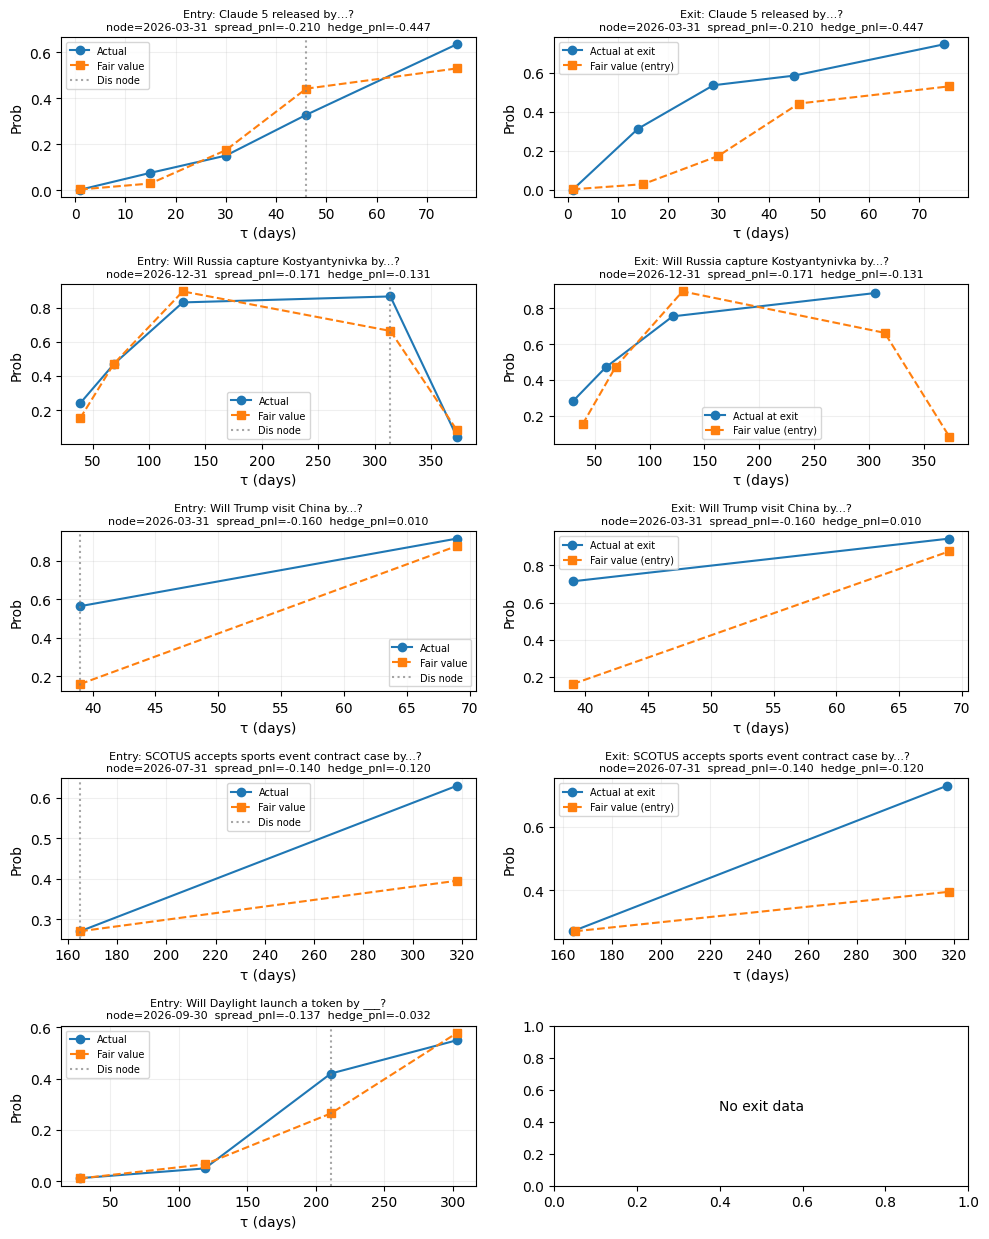

In [37]:
try:
    _trades = deduped_df
except NameError:
    _trades = trades_df

n_worst = 5
worst = _trades.nsmallest(n_worst, "spread_pnl").reset_index(drop=True)
if worst.empty:
    print("No trades to show.")
else:
    cols_show = ["event", "event_id", "dis_node", "hold_time", "spread_pnl", "hedge_pnl", "dis_pnl", "n_nodes"]
    display(worst[[c for c in cols_show if c in worst.columns]])

    fig, axes = plt.subplots(n_worst, 2, figsize=(10, 2.5 * n_worst))
    if n_worst == 1:
        axes = axes.reshape(1, -1)

    for i, (_, row) in enumerate(worst.iterrows()):
        eid, entry_ts, exit_ts = row["event_id"], row["entry_ts"], row["exit_ts"]
        dis_node = row["dis_node"]
        title = str(row["event"])[:50] + "..." if len(str(row["event"])) > 50 else str(row["event"])
        hold = row.get("hold_time", "—")
        sub = f"node={dis_node}  hold={hold}  spread_pnl={row.get('spread_pnl', 0):.3f}  hedge_pnl={row.get('hedge_pnl', 0):.3f}"

        entry_snap = panel_df[(panel_df["event_id"] == eid) & (panel_df["timestamp"] == entry_ts)]
        entry_snap = entry_snap.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
        if entry_snap.empty:
            axes[i, 0].text(0.5, 0.5, "No entry data", ha="center", va="center")
        else:
            tau = entry_snap["tau_days"].values
            actual = entry_snap["probability_yes"].values.astype(float)
            axes[i, 0].plot(tau, actual, "o-", label="Actual", color="C0")
            static_entry = static_df[(static_df["event_id"] == eid) & (static_df["timestamp"] == entry_ts)]
            static_entry = static_entry.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
            if not static_entry.empty and len(static_entry) == len(entry_snap):
                fair = static_entry["ts_predicted_prob"].values.astype(float)
                tau_f = static_entry["tau_days"].values
                axes[i, 0].plot(tau_f, fair, "s--", label="Fair value", color="C1")
            dis_tau = entry_snap[entry_snap["deadline_date"].astype(str) == str(dis_node)]["tau_days"].values
            if len(dis_tau) and dis_node in entry_snap["deadline_date"].values:
                axes[i, 0].axvline(dis_tau[0], color="gray", linestyle=":", alpha=0.7, label="Dis node")
            axes[i, 0].set_xlabel("τ (days)"); axes[i, 0].set_ylabel("Prob")
            axes[i, 0].set_title(f"Entry: {title}\n{sub}", fontsize=8); axes[i, 0].legend(loc="best", fontsize=7); axes[i, 0].grid(True, alpha=0.2)

        exit_snap = panel_df[(panel_df["event_id"] == eid) & (panel_df["timestamp"] == exit_ts)]
        exit_snap = exit_snap.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
        if exit_snap.empty:
            axes[i, 1].text(0.5, 0.5, "No exit data", ha="center", va="center")
        else:
            tau_ex = exit_snap["tau_days"].values
            actual_ex = exit_snap["probability_yes"].values.astype(float)
            axes[i, 1].plot(tau_ex, actual_ex, "o-", color="C0", label="Actual at exit")
            fair_at_entry = static_df[(static_df["event_id"] == eid) & (static_df["timestamp"] == entry_ts)]
            fair_at_entry = fair_at_entry.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
            if not fair_at_entry.empty:
                tau_f = fair_at_entry["tau_days"].values
                fair = fair_at_entry["ts_predicted_prob"].values.astype(float)
                axes[i, 1].plot(tau_f, fair, "s--", color="C1", label="Fair value (entry)")
            axes[i, 1].set_xlabel("τ (days)"); axes[i, 1].set_ylabel("Prob")
            axes[i, 1].set_title(f"Exit: {title}\n{sub}", fontsize=8); axes[i, 1].legend(loc="best", fontsize=7); axes[i, 1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

## 11. Backtest: fair value from 5- and 10-bar rolling reference

Recompute static signal and trades with `ref_smooth_bars` = 5 and 10 vs the current notebook baseline `REF_SMOOTH_BARS`.

**Why baseline shows 3:** your "original fair-value curve" in this notebook is already smoothed using `REF_SMOOTH_BARS = 3` (set in the config cell). So baseline = 3 is the current production setup. If you want the no-smoothing variant (only lagged bar), baseline would be `REF_SMOOTH_BARS = 1`.

,ref_smooth_bars,total_spread_pnl,total_spread_pnl_dollars,n_trades
0,3,2.7758,1387.9,105
1,5,3.5970,1798.5,105
2,10,5.2474,2623.7,113


Benchmark is your current strategy: REF_SMOOTH_BARS=3 (config baseline).


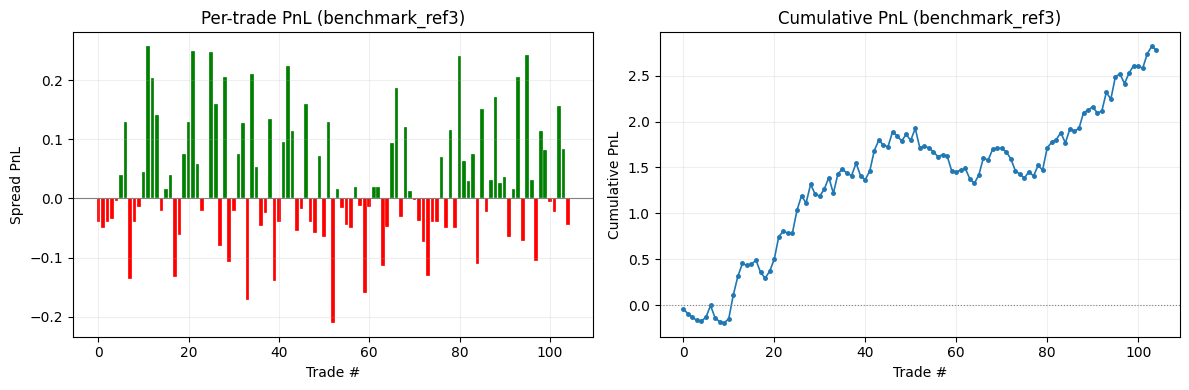

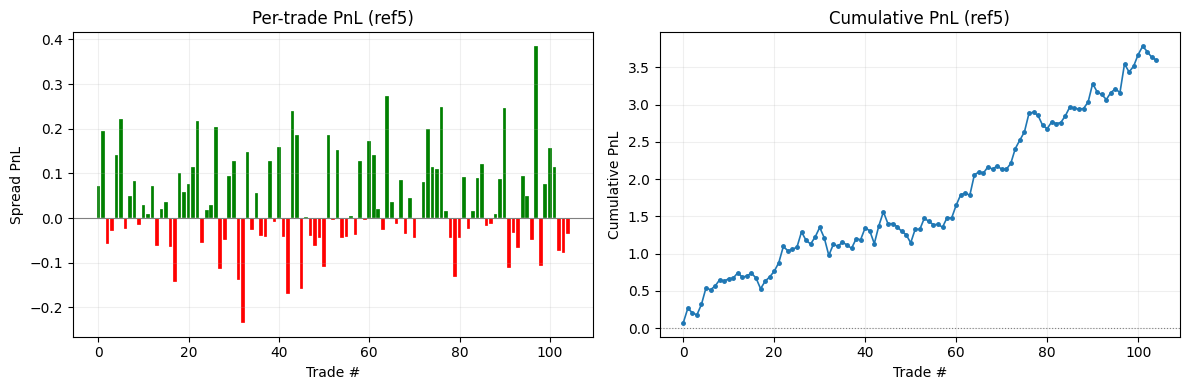

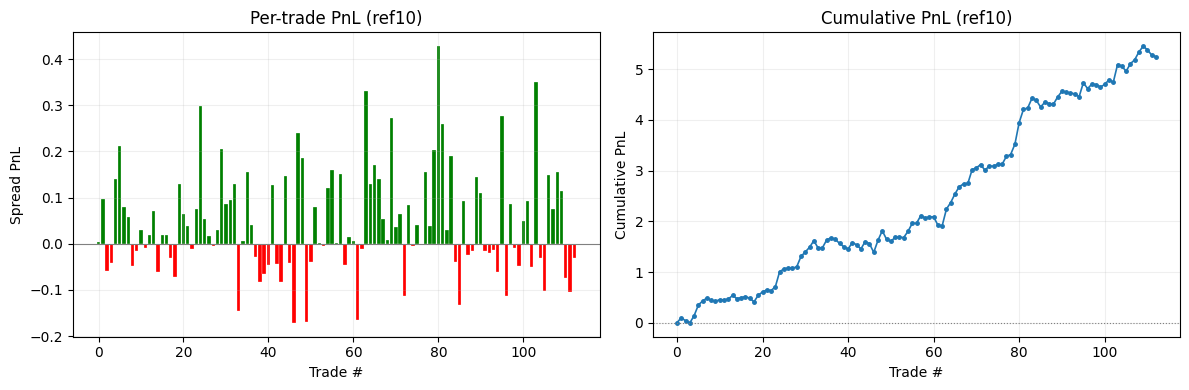

In [41]:
ref_smooth_options = [5, 10]
results_11 = []
for ref_smooth in ref_smooth_options:
    static_var = score_time_shifted_dislocations(
        panel_df,
        lag_bars=STATIC_LAG,
        min_nodes=STATIC_MIN_NODES,
        poly_degree=STATIC_POLY_DEGREE,
        ref_smooth_bars=ref_smooth,
    )
    static_var = static_var.dropna(subset=["ts_predicted_prob"])
    if EXCLUDE_POOR_FIT and warmup_end is not None:
        poor_var = event_ids_poor_static_fit_warmup(
            static_var, warmup_frac=POOR_FIT_WARMUP_FRAC,
            min_obs_per_event=POOR_FIT_MIN_OBS,
            exclude_worst_pct=POOR_FIT_EXCLUDE_WORST_PCT,
        )
        static_var = static_var[~static_var["event_id"].astype(str).isin(poor_var)]
    static_var["static_flag"] = static_var["ts_residual"].abs() >= STATIC_THRESHOLD
    static_var["direction"] = np.where(static_var["ts_residual"] < 0, "BUY", "SELL")
    signals_var = static_var[static_var["static_flag"]].copy()
    if warmup_end is not None:
        signals_var = signals_var[signals_var["timestamp"] > warmup_end]
    first_var = signals_var.sort_values("timestamp").copy()
    trades_var = build_trades_static_dislocation(
        first_var,
        panel_df,
        static_var,
        exit_threshold=EXIT_THRESHOLD,
        poly_degree=STATIC_POLY_DEGREE,
        resolution_map=resolution_map,
        event_deadlines=event_deadlines,
        latest_prices=latest_prices,
        spread_half=SPREAD_HALF,
        max_weight_per_leg=MAX_WEIGHT_PER_LEG,
        max_gross_hedge=MAX_GROSS_HEDGE,
        shares_per_trade=SHARES_PER_TRADE,
    )
    total_pnl = trades_var["spread_pnl"].sum() if not trades_var.empty else 0
    total_dollars = trades_var["spread_pnl_dollars"].sum() if not trades_var.empty and "spread_pnl_dollars" in trades_var.columns else np.nan
    results_11.append({"ref_smooth_bars": ref_smooth, "total_spread_pnl": total_pnl, "total_spread_pnl_dollars": total_dollars, "n_trades": len(trades_var)})

try:
    _df = deduped_df
except NameError:
    _df = trades_df
baseline_pnl = _df["spread_pnl"].sum() if not _df.empty else 0
baseline_dollars = _df["spread_pnl_dollars"].sum() if not _df.empty and "spread_pnl_dollars" in _df.columns else np.nan
results_11.insert(0, {"ref_smooth_bars": REF_SMOOTH_BARS, "total_spread_pnl": baseline_pnl, "total_spread_pnl_dollars": baseline_dollars, "n_trades": len(_df)})

results_11_df = pd.DataFrame(results_11).sort_values("ref_smooth_bars").reset_index(drop=True)
display(results_11_df)

print(f"Benchmark is your current strategy: REF_SMOOTH_BARS={REF_SMOOTH_BARS} (config baseline).")

# One chart pair per strategy (same style as Section 6: per-trade + cumulative)
strategy_runs = []
try:
    _benchmark_df = deduped_df.copy()
except NameError:
    _benchmark_df = trades_df.copy()
strategy_runs.append({"label": f"benchmark_ref{REF_SMOOTH_BARS}", "df": _benchmark_df})

for r in ref_smooth_options:
    # rebuild to keep an isolated run object for plotting
    static_run = score_time_shifted_dislocations(
        panel_df,
        lag_bars=STATIC_LAG,
        min_nodes=STATIC_MIN_NODES,
        poly_degree=STATIC_POLY_DEGREE,
        ref_smooth_bars=r,
    ).dropna(subset=["ts_predicted_prob"])
    if EXCLUDE_POOR_FIT and warmup_end is not None:
        poor_run = event_ids_poor_static_fit_warmup(
            static_run, warmup_frac=POOR_FIT_WARMUP_FRAC,
            min_obs_per_event=POOR_FIT_MIN_OBS,
            exclude_worst_pct=POOR_FIT_EXCLUDE_WORST_PCT,
        )
        static_run = static_run[~static_run["event_id"].astype(str).isin(poor_run)]
    static_run["static_flag"] = static_run["ts_residual"].abs() >= STATIC_THRESHOLD
    static_run["direction"] = np.where(static_run["ts_residual"] < 0, "BUY", "SELL")
    sig_run = static_run[static_run["static_flag"]].copy()
    if warmup_end is not None:
        sig_run = sig_run[sig_run["timestamp"] > warmup_end]
    sig_run = sig_run.sort_values("timestamp").copy()
    tr_run = build_trades_static_dislocation(
        sig_run,
        panel_df,
        static_run,
        exit_threshold=EXIT_THRESHOLD,
        poly_degree=STATIC_POLY_DEGREE,
        resolution_map=resolution_map,
        event_deadlines=event_deadlines,
        latest_prices=latest_prices,
        spread_half=SPREAD_HALF,
        max_weight_per_leg=MAX_WEIGHT_PER_LEG,
        max_gross_hedge=MAX_GROSS_HEDGE,
        shares_per_trade=SHARES_PER_TRADE,
    )
    strategy_runs.append({"label": f"ref{r}", "df": tr_run})

for run in strategy_runs:
    run_df = run["df"]
    if run_df is None or run_df.empty or "spread_pnl" not in run_df.columns:
        print(f"No trades to plot for {run['label']}.")
        continue

    pnl = run_df["spread_pnl"].reset_index(drop=True)
    cum = pnl.cumsum()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = np.where(pnl >= 0, "green", "red")
    axes[0].bar(range(len(pnl)), pnl, color=colors, edgecolor="white", linewidth=0.2)
    axes[0].axhline(0, color="gray", linewidth=0.8)
    axes[0].set_title(f"Per-trade PnL ({run['label']})")
    axes[0].set_xlabel("Trade #")
    axes[0].set_ylabel("Spread PnL")
    axes[0].grid(True, alpha=0.2)

    axes[1].plot(range(len(cum)), cum, marker="o", markersize=2.5, linewidth=1.2)
    axes[1].axhline(0, color="gray", linewidth=0.8, linestyle=":")
    axes[1].set_title(f"Cumulative PnL ({run['label']})")
    axes[1].set_xlabel("Trade #")
    axes[1].set_ylabel("Cumulative PnL")
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

## 12. Correlation: spread PnL vs hedge PnL

Investigate whether spread PnL and hedge PnL move together across trades (e.g. hedge loses when spread loses).

Correlation(spread_pnl, hedge_pnl) = 0.5545


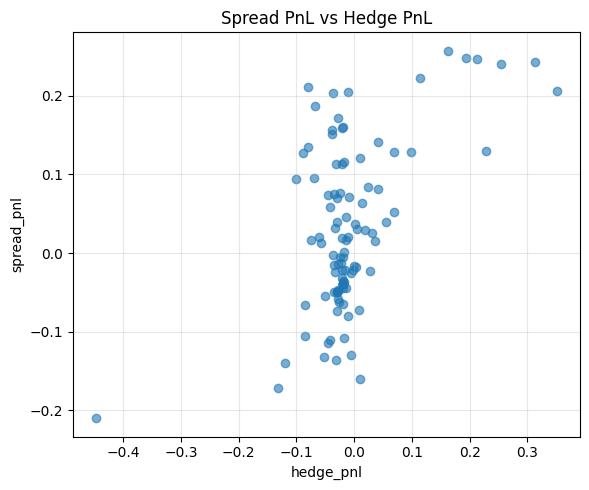

In [39]:
try:
    _df12 = deduped_df
except NameError:
    _df12 = trades_df
if _df12.empty or "spread_pnl" not in _df12.columns or "hedge_pnl" not in _df12.columns:
    print("No trades or missing spread_pnl/hedge_pnl columns.")
else:
    corr = _df12["spread_pnl"].corr(_df12["hedge_pnl"])
    print(f"Correlation(spread_pnl, hedge_pnl) = {corr:.4f}")
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(_df12["hedge_pnl"], _df12["spread_pnl"], alpha=0.6)
    ax.set_xlabel("hedge_pnl"); ax.set_ylabel("spread_pnl")
    ax.set_title("Spread PnL vs Hedge PnL"); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 13. Residual curves for 5 random trades (ref10)

Visualize `ts_residual` across tenors at **entry** and **exit** for 5 random exited trades using fair value built with `ref_smooth_bars = 10`.

,event,event_id,dis_node,hold_time,spread_pnl,hedge_pnl,dis_pnl
0,Will Daylight launch a token by ___?,106176,2026-09-30,111.0h,0.1285,0.0685,0.0600
1,Will Oro launch a token by ___?,127102,2026-09-30,6.0h,0.0547,-0.0403,0.0950
2,Will Pacifica launch a token by ___ ?,84945,2026-06-30,5.0h,0.1409,0.1309,0.0100
3,SCOTUS accepts sports event contract case by...?,32565,2026-07-31,6.0h,0.1600,0.1800,-0.0200
4,Will a new country buy Bitcoin by...?,80825,2026-12-31,3.0h,0.2400,0.2600,-0.0200
5,Will Tempo launch a token by ___ ?,90366,2026-09-30,28.0h,0.0867,0.0417,0.0450
6,Foreign intervention in Gaza by..?,73339,2026-06-30,12.0h,-0.1045,-0.0245,-0.0800
7,Will Trump visit China by...?,46859,2026-03-31,10.0h,-0.1695,0.0150,-0.1845
8,Will MetaMask launch a token by ___ ?,46724,2026-12-31,6.0h,0.0200,-0.0100,0.0300
9,MegaETH airdrop by...?,29005,2027-02-15,14.0h,0.0043,0.0278,-0.0235


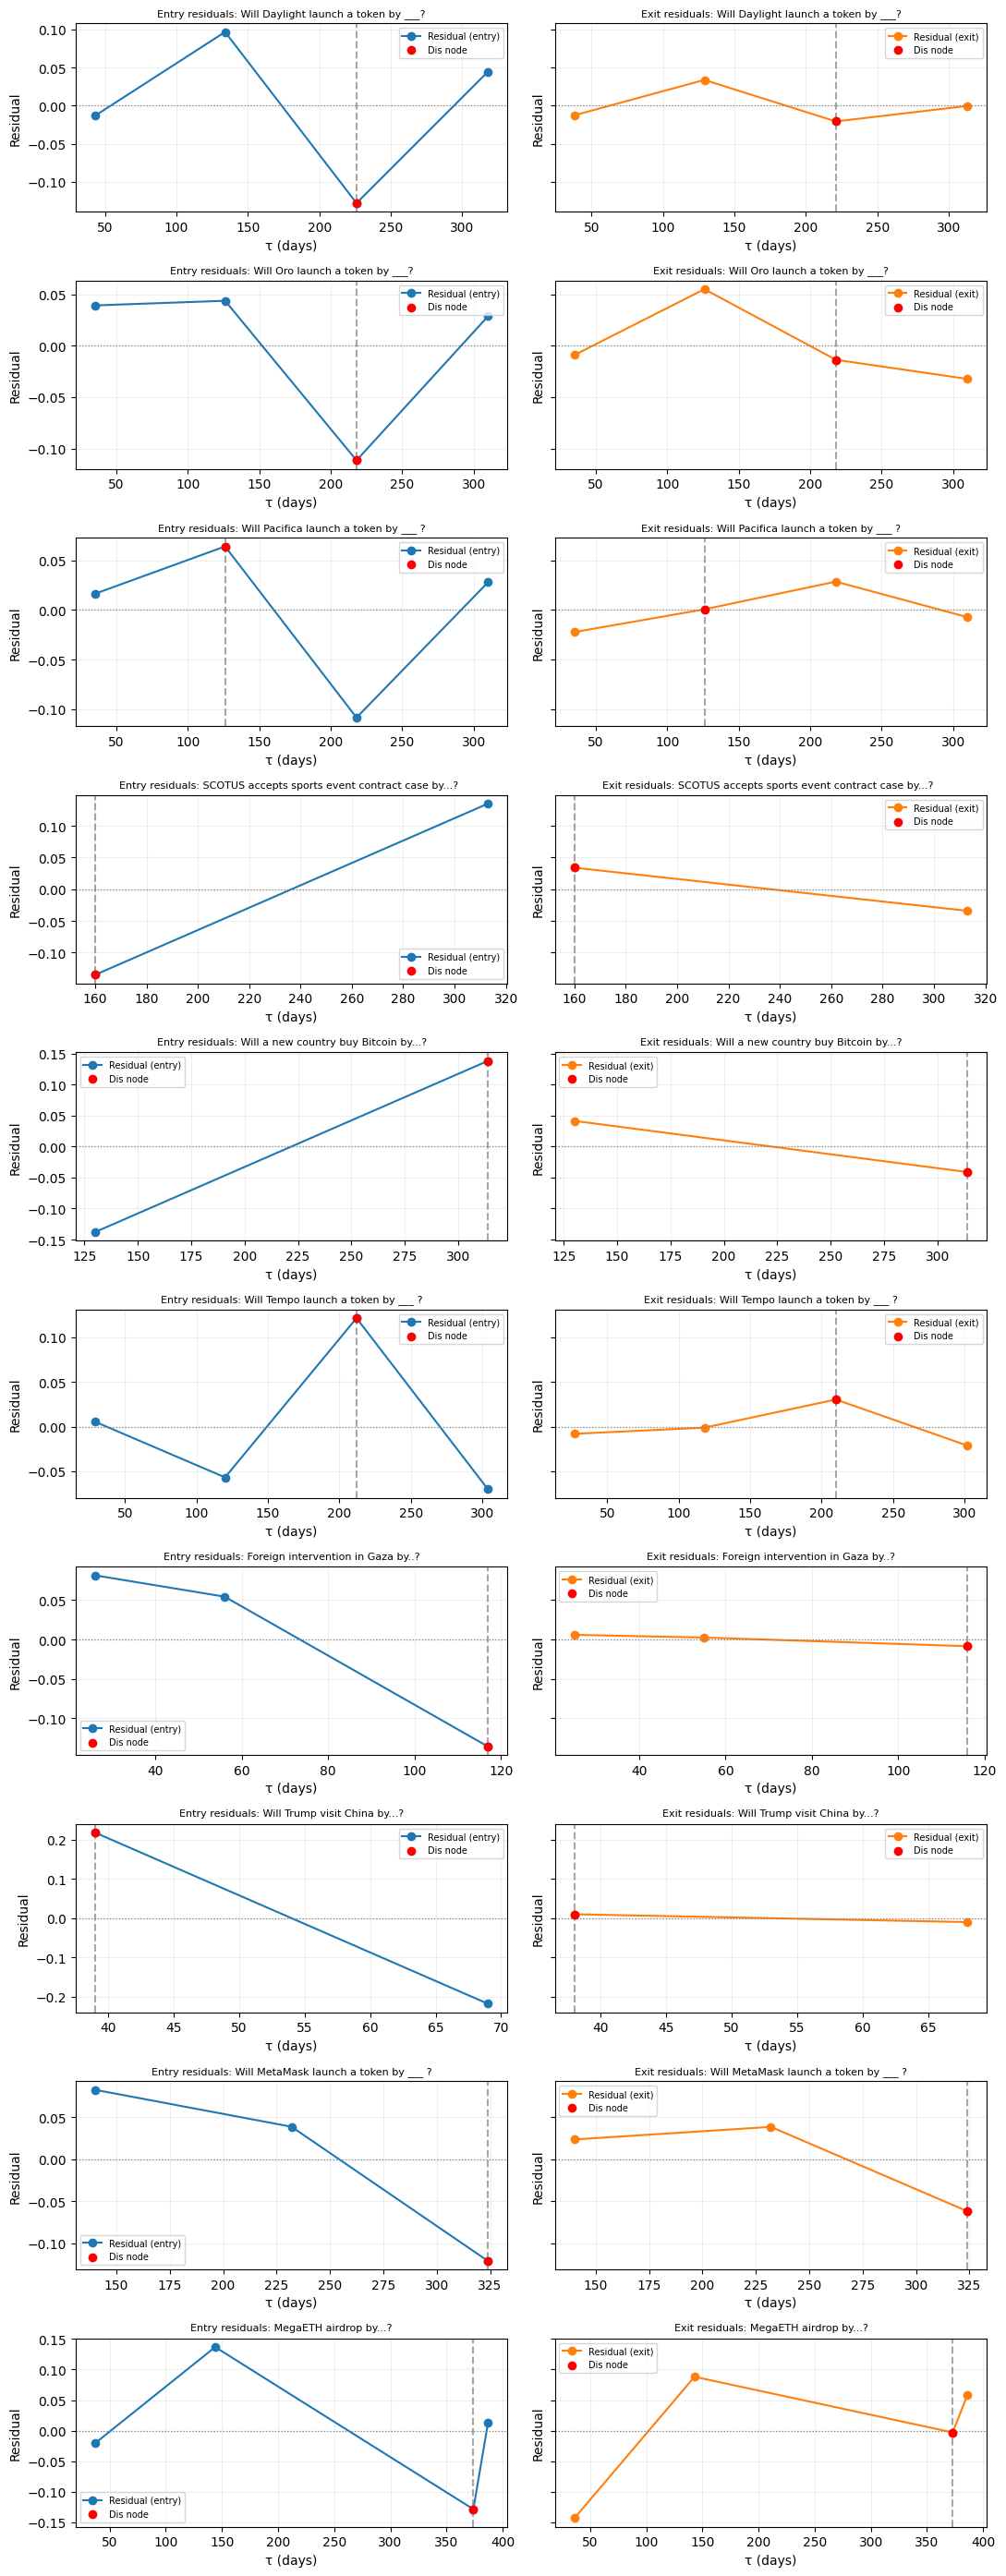

In [43]:
# Build static signal with ref10 and plot residual curves for 5 random exited trades
REF10 = 10

static_ref10 = score_time_shifted_dislocations(
    panel_df,
    lag_bars=STATIC_LAG,
    min_nodes=STATIC_MIN_NODES,
    poly_degree=STATIC_POLY_DEGREE,
    ref_smooth_bars=REF10,
)
static_ref10 = static_ref10.dropna(subset=["ts_predicted_prob"]).copy()

if EXCLUDE_POOR_FIT and "warmup_end" in dir() and warmup_end is not None:
    poor_ref10 = event_ids_poor_static_fit_warmup(
        static_ref10,
        warmup_frac=POOR_FIT_WARMUP_FRAC,
        min_obs_per_event=POOR_FIT_MIN_OBS,
        exclude_worst_pct=POOR_FIT_EXCLUDE_WORST_PCT,
    )
    static_ref10 = static_ref10[~static_ref10["event_id"].astype(str).isin(poor_ref10)]

static_ref10["static_flag"] = static_ref10["ts_residual"].abs() >= STATIC_THRESHOLD
static_ref10["direction"] = np.where(static_ref10["ts_residual"] < 0, "BUY", "SELL")

signals_ref10 = static_ref10[static_ref10["static_flag"]].copy()
if "warmup_end" in dir() and warmup_end is not None:
    signals_ref10 = signals_ref10[signals_ref10["timestamp"] > warmup_end]
first_ref10 = signals_ref10.sort_values("timestamp").copy()

trades_ref10 = build_trades_static_dislocation(
    first_ref10,
    panel_df,
    static_ref10,
    exit_threshold=EXIT_THRESHOLD,
    poly_degree=STATIC_POLY_DEGREE,
    resolution_map=resolution_map,
    event_deadlines=event_deadlines,
    latest_prices=latest_prices,
    spread_half=SPREAD_HALF,
    max_weight_per_leg=MAX_WEIGHT_PER_LEG,
    max_gross_hedge=MAX_GROSS_HEDGE,
    shares_per_trade=SHARES_PER_TRADE,
)

exited_ref10 = trades_ref10[trades_ref10["status"] == "E"].dropna(subset=["exit_ts"]).copy()
if exited_ref10.empty:
    print("No exited trades in ref10 run.")
else:
    n_show = min(10, len(exited_ref10))
    sample_ref10 = exited_ref10.sample(n=n_show, random_state=42).reset_index(drop=True)

    cols = ["event", "event_id", "dis_node", "hold_time", "spread_pnl", "hedge_pnl", "dis_pnl"]
    display(sample_ref10[[c for c in cols if c in sample_ref10.columns]])

    fig, axes = plt.subplots(n_show, 2, figsize=(11, 2.8 * n_show), sharey="row")
    if n_show == 1:
        axes = axes.reshape(1, -1)

    for i, (_, tr) in enumerate(sample_ref10.iterrows()):
        eid, entry_ts, exit_ts = tr["event_id"], tr["entry_ts"], tr["exit_ts"]
        dis_node = tr["dis_node"]
        title = str(tr["event"])[:52] + "..." if len(str(tr["event"])) > 52 else str(tr["event"])

        # Entry residual curve
        en = static_ref10[(static_ref10["event_id"] == eid) & (static_ref10["timestamp"] == entry_ts)]
        en = en.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
        if en.empty:
            axes[i, 0].text(0.5, 0.5, "No entry residual data", ha="center", va="center")
        else:
            tau_en = en["tau_days"].values
            res_en = en["ts_residual"].values.astype(float)
            axes[i, 0].plot(tau_en, res_en, "o-", color="C0", label="Residual (entry)")
            axes[i, 0].axhline(0, color="gray", linestyle=":", linewidth=0.9)
            dis_tau_en = en[en["deadline_date"].astype(str) == str(dis_node)]["tau_days"].values
            dis_res_en = en[en["deadline_date"].astype(str) == str(dis_node)]["ts_residual"].values
            if len(dis_tau_en):
                axes[i, 0].axvline(dis_tau_en[0], color="gray", linestyle="--", alpha=0.7)
                axes[i, 0].scatter(dis_tau_en[0], dis_res_en[0], color="red", zorder=3, label="Dis node")
            axes[i, 0].set_xlabel("τ (days)")
            axes[i, 0].set_ylabel("Residual")
            axes[i, 0].set_title(f"Entry residuals: {title}", fontsize=8)
            axes[i, 0].legend(loc="best", fontsize=7)
            axes[i, 0].grid(True, alpha=0.2)

        # Exit residual curve
        ex = static_ref10[(static_ref10["event_id"] == eid) & (static_ref10["timestamp"] == exit_ts)]
        ex = ex.drop_duplicates(subset=["deadline_date"], keep="last").sort_values("tau_days")
        if ex.empty:
            axes[i, 1].text(0.5, 0.5, "No exit residual data", ha="center", va="center")
        else:
            tau_ex = ex["tau_days"].values
            res_ex = ex["ts_residual"].values.astype(float)
            axes[i, 1].plot(tau_ex, res_ex, "o-", color="C1", label="Residual (exit)")
            axes[i, 1].axhline(0, color="gray", linestyle=":", linewidth=0.9)
            dis_tau_ex = ex[ex["deadline_date"].astype(str) == str(dis_node)]["tau_days"].values
            dis_res_ex = ex[ex["deadline_date"].astype(str) == str(dis_node)]["ts_residual"].values
            if len(dis_tau_ex):
                axes[i, 1].axvline(dis_tau_ex[0], color="gray", linestyle="--", alpha=0.7)
                axes[i, 1].scatter(dis_tau_ex[0], dis_res_ex[0], color="red", zorder=3, label="Dis node")
            axes[i, 1].set_xlabel("τ (days)")
            axes[i, 1].set_ylabel("Residual")
            axes[i, 1].set_title(f"Exit residuals: {title}", fontsize=8)
            axes[i, 1].legend(loc="best", fontsize=7)
            axes[i, 1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

Derived address:  0x5Bb23d96df84A29E9ECAa548804Ee364Eb70BFdf
Funder address:   0xf2faf524fdf5901cf0f6e7a2eaae3f0c4e9f4a62
Match:            False
